<br/>

<div align="center">
<span style="font-size: 2.5em;">SBI Training Results and Inference</span>
<br/>
<span style="font-size: 1.2em; color: gray;">Visualization of trained S1S2 models and posterior inference (Signal + Background)</span>
</div>

## Overview

This notebook mirrors the signal-only workflow, but uses **signal + background** spectra to demonstrate inference and exclusion under realistic contamination.

**Workflow:**

1. **Setup**: Load trained model and prepare datasets
2. **Training Analysis**: Visualize loss and accuracy curves
3. **Posterior Inference**: Example posteriors and a grid view
4. **HPD Exclusions**: Show why background fluctuations matter
5. **Marginalized Limits**: Compute robust limits and apply a critical-mass cut

**Note:** Model training is handled in the training scripts; this notebook focuses on visualization and interpretation.

## 1. Setup and Configuration

Import required libraries and set up paths to access the project modules.

In [1]:
# =============================
# IMPORTS AND PATH SETTINGS
# =============================

import os
import importlib
desired_root_name = "xenon-sbi" 
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

import torch
import numpy as np

from configs.config import load_model_s1s2, PARAM_RANGES
from utils.training import plot_training_summary
import utils.posteriors as posteriors
importlib.reload(posteriors)

from utils.posteriors import (
    plot_posterior_single_s1s2,
    plot_posterior_grid_s1s2,
    plot_null_exclusion_s1s2,
    compute_marginalized_limit_statistics,
    plot_marginalized_limits_with_bands,
    plot_hpd_contours_multiple_bg_realizations,
    plot_multiple_marginalized_limits,
    determine_critical_mass,
    compute_profile_likelihood_limit_statistics,
    plot_profile_likelihood_limits_with_bands,
 )
from utils.processing import load_s1s2_valloader

### Model and Data Configuration

Specify the model, data regime, and background settings for the signal+background case.

In [2]:
# --- Model and data settings ---
modelname = "S1S2_signal_bg"
halo      = "shm"
datatag   = "low"
n_train   = 300_000
bins      = 10

# Background settings
mu_bg = 150  

# Evaluation settings
n_eval = 5000  # lighter subsample for evaluation

logm_range = PARAM_RANGES[datatag]["logm_range"]
logcp_range = PARAM_RANGES[datatag]["logcp_range"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Load Trained Model

Load the pre-trained classifier that distinguishes signal+background from mismatched pairs.

In [3]:
signal_type = "signal_only" if mu_bg == 0 else f"signal_bg_mu{mu_bg:.0f}"
SIGNAL_PT = f"data/datasets/xenon/s1s2/pt/s1s2_n{n_train}_{halo}.pt"
bg_CSV = "data/datasets/xenon/s1s2/ers/s1s2_ers.csv"
MODELPATH = f"models/xenon/{signal_type}/{halo}/{modelname}_bins{bins}_n{n_train}_{halo}.pt"
print(f"Loading model from:\n{MODELPATH}\n")

model, ckpt = load_model_s1s2(MODELPATH, bins=bins, modelname=modelname, device=device, print_arch=True)

Loading model from:
models/xenon/signal_bg_mu150/shm/S1S2_signal_bg_bins10_n300000_shm.pt

S1S2_signal_bg(
  (net): Sequential(
    (0): Linear(in_features=102, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): SiLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): SiLU()
    (15): Dropout(p=0.2, inplace=False)
    (16): Linear(in_features=64, out_features=64,

### Prepare Validation Dataset

Load the signal library and background pool, then construct a validation dataloader.

In [12]:
val_loader, bg_events = load_s1s2_valloader(SIGNAL_PT, bg_CSV, mu_bg=mu_bg, bins=bins, n_eval=n_eval)

Validation pairs: 10,000


## 2. Training Analysis

Visualize the training history to assess convergence and performance.


Training Summary
────────────────────────────────────────────
Best validation loss:     0.509
Best validation accuracy: 0.699
────────────────────────────────────────────


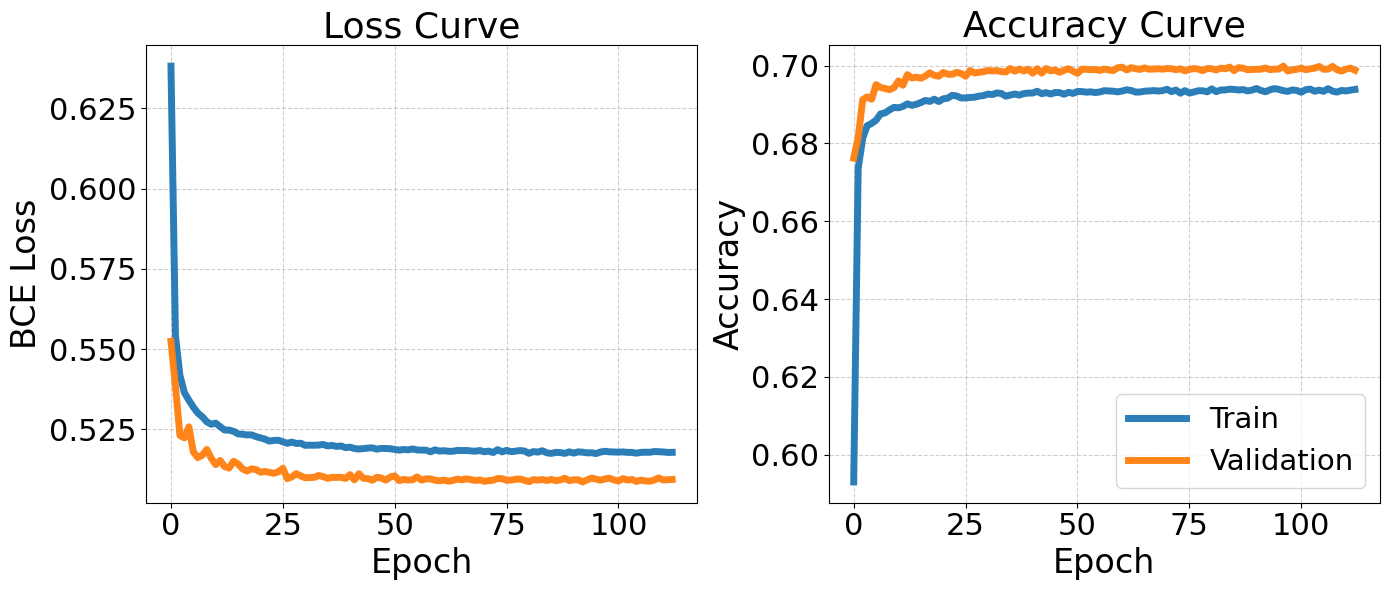

In [6]:
plot_training_summary(ckpt)

## 3. Posterior Inference

Demonstrate inference by generating posteriors for selected parameter points and a grid.

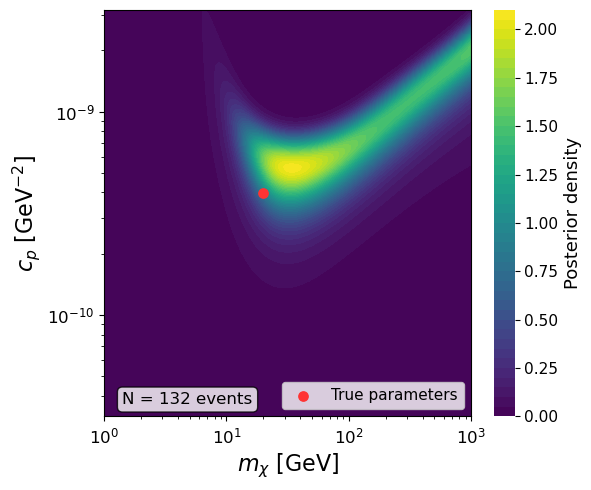

In [7]:
plot_posterior_single_s1s2(
    model=model,
    val_loader=val_loader,
    mchi=20.0,
    cp=10**(-9.4),
    #credible_levels=[0.68, 0.95],
    y_quantity="cp"
 )

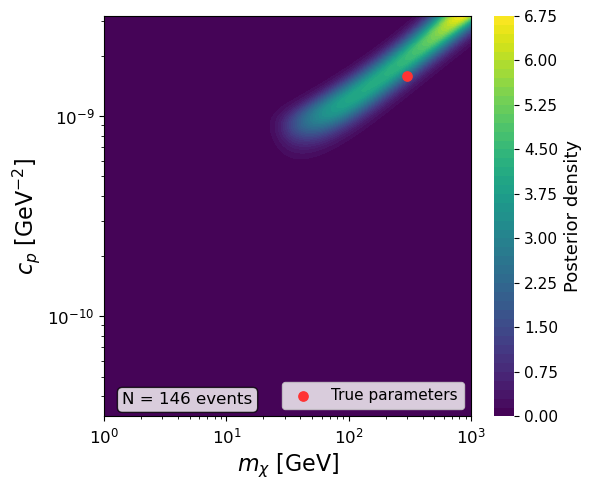

In [8]:
plot_posterior_single_s1s2(
    model=model,
    val_loader=val_loader,
    mchi=300,
    cp=10**(-8.80),
    #credible_levels=[0.68, 0.95],
    y_quantity="cp",
)

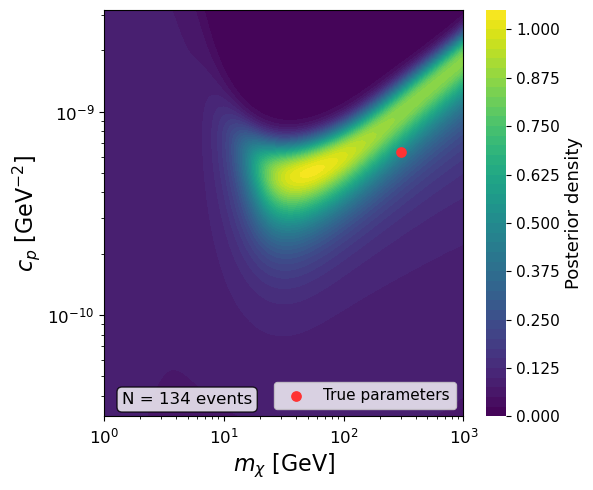

In [9]:
plot_posterior_single_s1s2(
    model=model,
    val_loader=val_loader,
    mchi=300,
    cp=10**(-9.20),
    #credible_levels=[0.68, 0.95],
    y_quantity="cp",
)

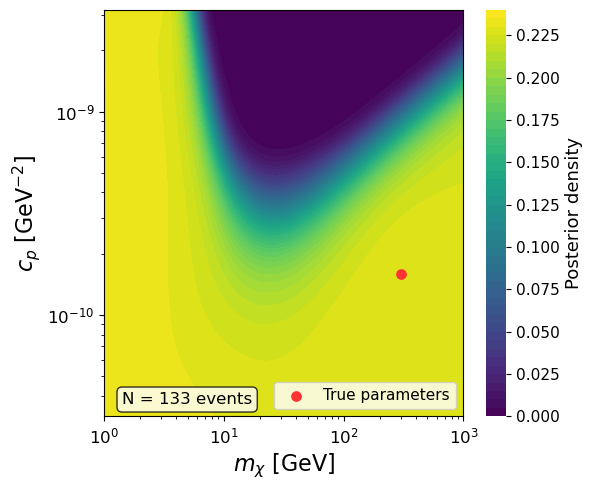

In [10]:
plot_posterior_single_s1s2(
    model=model,
    val_loader=val_loader,
    mchi=300,
    cp=10**(-9.80),
    #credible_levels=[0.68, 0.95],
    y_quantity="cp",
)

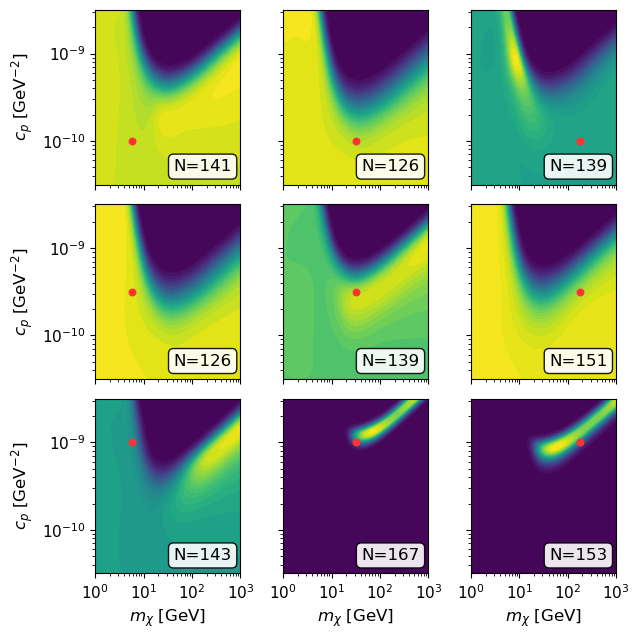

In [11]:
plot_posterior_grid_s1s2(
    model=model,
    val_loader=val_loader, 
    grid_dim=3, 
    #save_path=f"figures/...",
 )

**Key Insight:** Posteriors now reflect both **signal and background**, so localization and width depend on background fluctuations as well as the signal strength.

## 4. HPD Credible-Region Exclusions

In the signal+background setting, HPD contours vary across background realizations. This section shows why a single contour is not a stable exclusion curve.

### 4.1 Single Background Realization

Compute the HPD contour for one background-only spectrum as a reference.

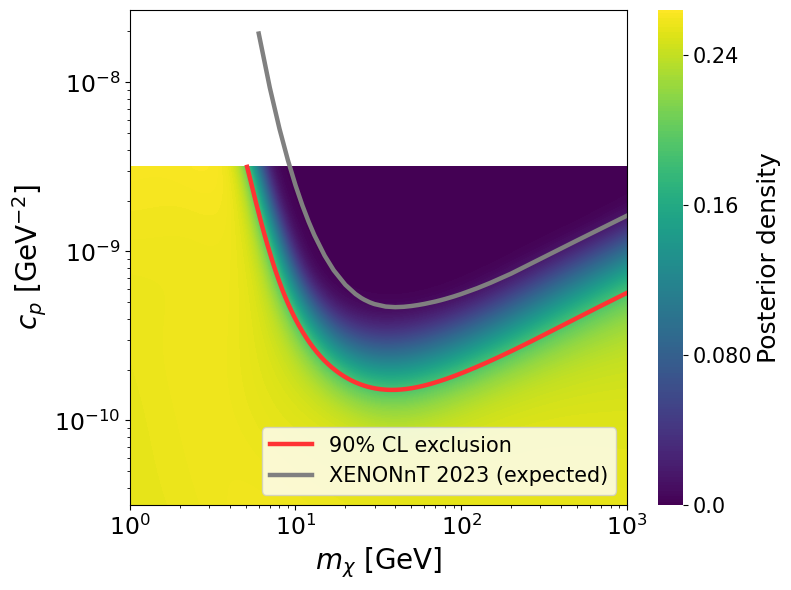

In [12]:
plot_null_exclusion_s1s2(
    model=model,
    background_events=bg_events,
    mu_bg=mu_bg,
    bins=bins,
    rng_seed=42,
    plot_official_xenonnt=True,
    y_quantity="cp",
)

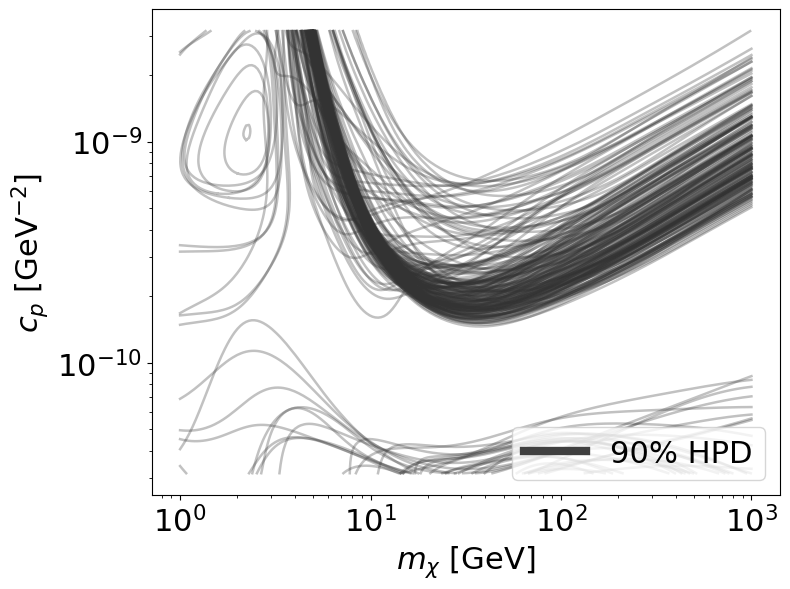

In [13]:
# =====================================================
# MULTIPLE BACKGROUND REALIZATIONS (HPD CONTOURS)
# =====================================================

plot_hpd_contours_multiple_bg_realizations(
    background_events=bg_events,
    mu_bg=mu_bg,
    bins=bins,
    model=model,
    n_realizations=200,
    linewidth=1.8,
    legend_linewidth=6.0,
    legend_fontsize=22,
    legend_color=(0.25, 0.25, 0.25, 1.0),
    #save_path=f"figures/...",
)

---

## 5. Exclusion Analysis: Marginalized Upper Limits

To stabilize exclusions under background fluctuations, we switch to **marginalized upper limits** and summarize them statistically.

**Minimal method:**
1. Marginalize $p(m_\chi, c_p | \text{data}) \rightarrow p(c_p | m_\chi)$
2. Extract the 90% CL upper limit at each mass
3. Repeat over many background realizations
4. Summarize with median and percentile bands

**Critical mass:** Below a data-driven threshold, limits become flat or just unreliable. We detect this transition and mask the low-mass region in plots.

### 5.1 Overlaid Upper Limit Curves

Plot the upper limits from many background realizations to visualize variability.

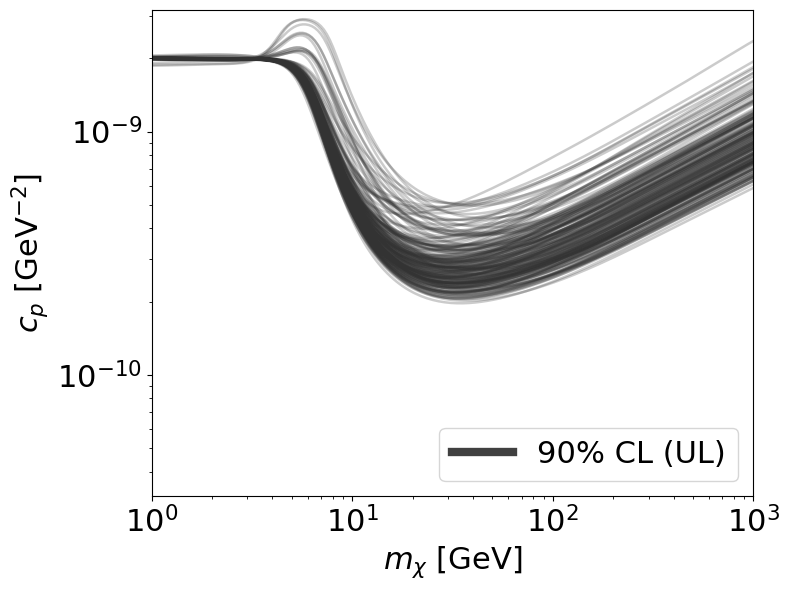

In [14]:
# =================================================================
# MULTIPLE BACKGROUND REALIZATIONS (Marginalized Upper limits)
# =================================================================

plot_multiple_marginalized_limits(
    background_events=bg_events,
    mu_bg=mu_bg,
    bins=bins,
    model=model,
    n_realizations=200,
    linewidth=1.8,
    legend_linewidth=6.0,
    legend_color=(0.25, 0.25, 0.25, 1.0),
    legend_fontsize=22,
    #save_path=f"figures/...",
)

### 5.2 Compute Exclusion Statistics

Aggregate the realizations into median and percentile bands.

In [15]:
# Compute marginalized limit statistics
stats, logm_vals, logcp_limits_list = compute_marginalized_limit_statistics(
    background_events=bg_events,
    mu_bg=mu_bg,
    bins=bins,
    model=model,
    n_realizations=200,
)

print(f"\nComputed {len(logcp_limits_list)} marginalized upper limits")
print(f"Statistics available: {list(stats.keys())}")


Computed 200 marginalized upper limits
Statistics available: ['mean', 'median', 'p16', 'p84', 'p2p5', 'p97p5', 'n_valid']


Plot the median limit with 68% and 95% bands to see the unmasked low-mass region.

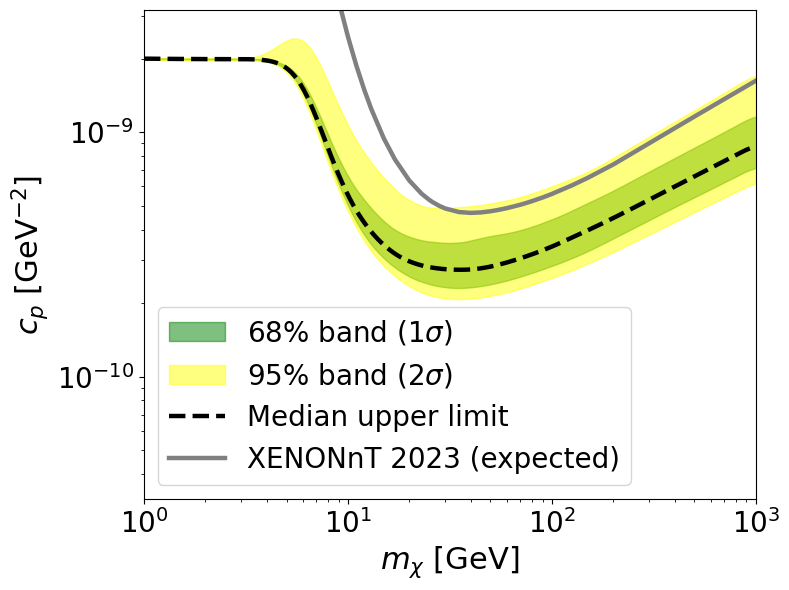

In [16]:
# Plot with uncertainty bands (no threshold yet)
plot_marginalized_limits_with_bands(
    logm_vals=logm_vals,
    stats=stats,
    show_mean=False,
    axis_label_fontsize=22,
    tick_label_fontsize=20,
    legend_fontsize=20,
    y_quantity="cp",
    plot_official_xenonnt=True,
)

### 5.3 Determine Critical Mass Threshold

Estimate the mass where the median curve transitions from flat to varying using a slope-based criterion.

In [17]:
# Determine critical mass 
critical_mass = determine_critical_mass(logm_vals, stats)

Critical Mass: 7.8 GeV


### 5.4 Overlaid Limits (with Threshold)

Replot individual curves with the critical mass line for a quick sanity check.

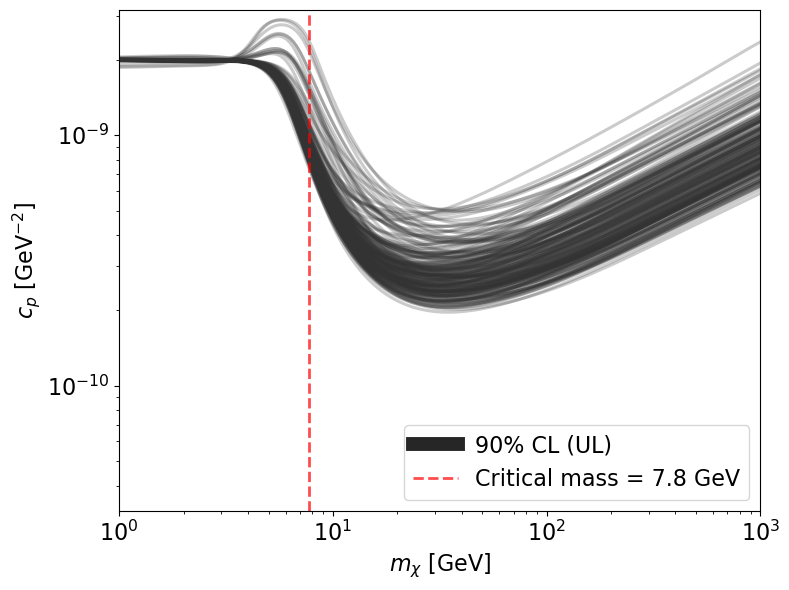

In [18]:
# Plot overlaid limits
plot_multiple_marginalized_limits(
    background_events=bg_events,
    mu_bg=mu_bg,
    bins=bins,
    model=model,
    n_realizations=200,
    critical_mass_line=critical_mass,
    legend_linewidth=10.0,
    legend_color=(0.15, 0.15, 0.15, 1.0),
)

### 5.5 Final Statistical Summary (with Threshold)

Plot the reportable exclusion curve with uncertainty bands after masking the low-mass region.

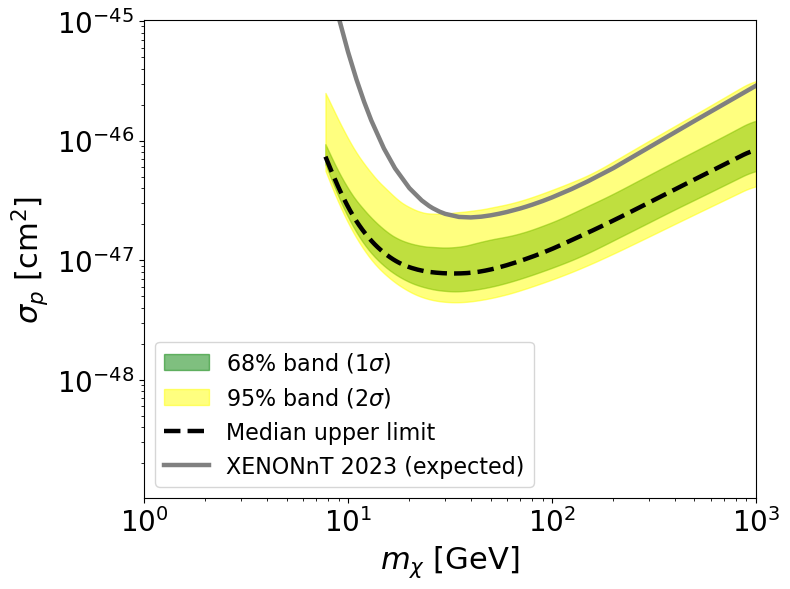

In [19]:
# Plot with uncertainty bands and critical mass applied
plot_marginalized_limits_with_bands(
    logm_vals=logm_vals,
    stats=stats,
    critical_mass=critical_mass,
    show_mean=False,
    axis_label_fontsize=22,
    tick_label_fontsize=20,
    legend_fontsize=16,
    y_quantity="sigma",
    plot_official_xenonnt=True,
    #save_path=f"figures/...",
)

### Prior Sensitivity Problem

Critical Mass: 7.8 GeV


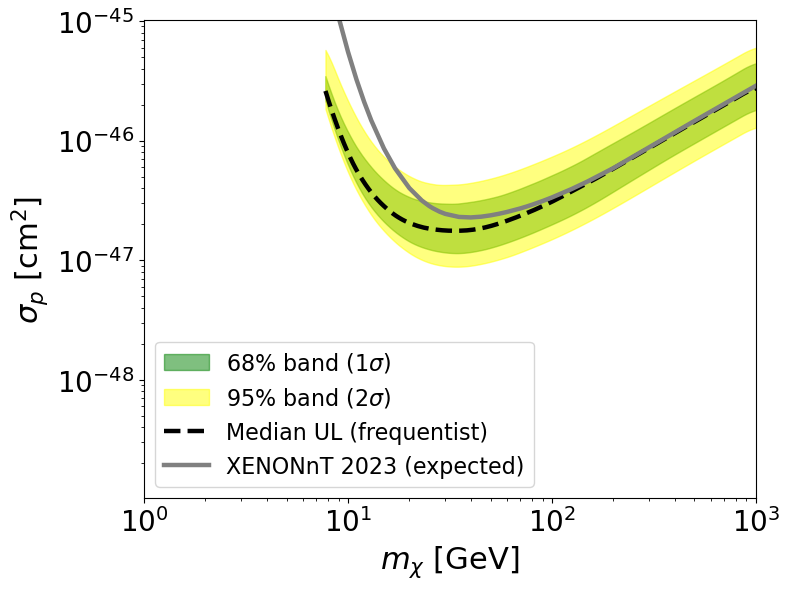

In [20]:
# =====================================================
# FREQUENTIST PROFILE-LIKELIHOOD EXCLUSION (S1S2 bg)
# =====================================================

stats_freq, logm_vals_freq, logcp_limits_list_freq = compute_profile_likelihood_limit_statistics(
    background_events=bg_events,
    mu_bg=mu_bg,
    bins=bins,
    logm_range=logm_range,
    logcp_range=logcp_range,
    model=model,
    device=device,
    n_realizations=200,
    seed_offset=0,
    posteriorbins=200,
    wilks_q=2.71,
    cl=0.90,
    smoothing_window=10,
 )

critical_mass_freq = determine_critical_mass(logm_vals_freq, stats_freq)

plot_profile_likelihood_limits_with_bands(
    logm_vals=logm_vals_freq,
    stats=stats_freq,
    critical_mass=critical_mass_freq,
    show_mean=False,
    axis_label_fontsize=22,
    tick_label_fontsize=20,
    legend_fontsize=16,
    y_quantity="sigma",
    plot_official_xenonnt=True,
    #save_path=f"figures/...",
 )